# EDA of California Housing dataset:
 objective of California Housing dataset EDA
- Perform a complete EDA on a large, all-numeric dataset
- Detect censored data and extreme outliers
- Build geographic scatter plots to reveal spatial patterns

# Importing necessary libraries

In [38]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import kagglehub
import os

# Loading dataset


In [39]:

path = kagglehub.dataset_download("camnugent/california-housing-prices") 
print("Path to dataset files:", path) 
file_path = os.path.join(path, "housing.csv") 
df = pd.read_csv(file_path) 
df.head()

Path to dataset files: C:\Users\Asus\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Inspecting dataset

In [40]:
print(f'Dimensions of dataset: {df.shape}')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print(f'Columns_Names: {df.columns}')

Dimensions of dataset: (20640, 10)
Rows: 20640
Columns: 10
Columns_Names: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [42]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Understanding of dataset
There are 20640 rows or instances in the dataset and 10 columns or features.Each row represents a **census block group**. The data doesn't represent invidival houses.

The dataset contains demographic, geographic, and housing related features for different regions in California. The features are:
- **Longitude**: Block group longitude (continuous variable)
- **Latitude**: Block group latitude (continuous variable)
- **housing_median_age**: Median house age in years in a block (discrete variable)
- **total_rooms**:Total number of rooms in a block (continuous variable)
- **total_bedrooms**:Total number of bedrooms in a block(continuous variable)
- **population**:Total population residing in the block (discrete variable)
- **households**:Total number of households in the block (discrete variable)
- **median_income**: Median income in $10,000s (continuous variable)

- **median_house_value**: median value of house in block in $100,000s (target/continuous variable)
- **ocean_proximity**:Categorical variable indicating the proximity of the block to the ocean(Categorical-Nominal variable)

**Key observation:** There seems to be missing values in total_bedrooms.lets see more on this using isnull().sum() function.

# Handaling Missing values

In [43]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

There are 207 missing values in total_ bedrooms attribute. Lets fill missing data with meadian

In [44]:
df_filled =df.copy()
df_filled = df_filled.fillna(df['total_bedrooms'].median())
df_filled.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Now, the data has no missing values


# Data Visualization

Lets examine the target variable


<Axes: >

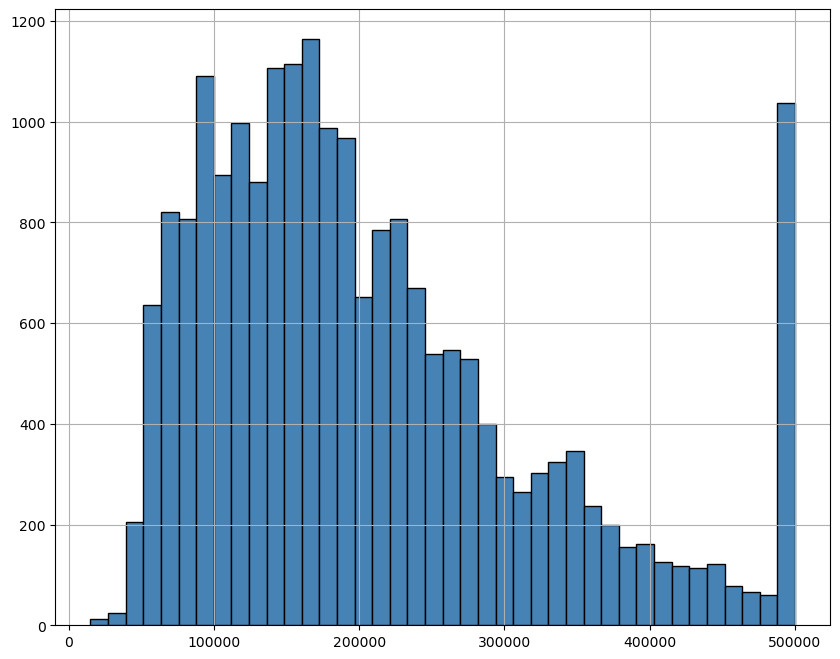

In [45]:
df_filled['median_house_value'].hist(bins=40, color="steelblue", edgecolor="black", figsize=(10,8))

In [46]:
df_filled['median_house_value'].max()

500001.0

data is capped at 500001(data above 500000 are censored) because 1990 census didn't record home value above 500001

<Axes: ylabel='median_house_value'>

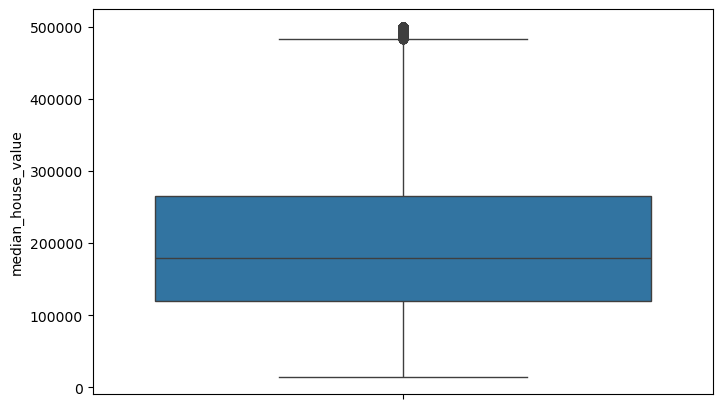

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(df_filled['median_house_value'])


Since, The median line is closer to the bottom of the box.The top whisker is much longer than the bottom whisker.Most outliers appear as dots above the top whisker. It is Right skewed.

lets examine all the features

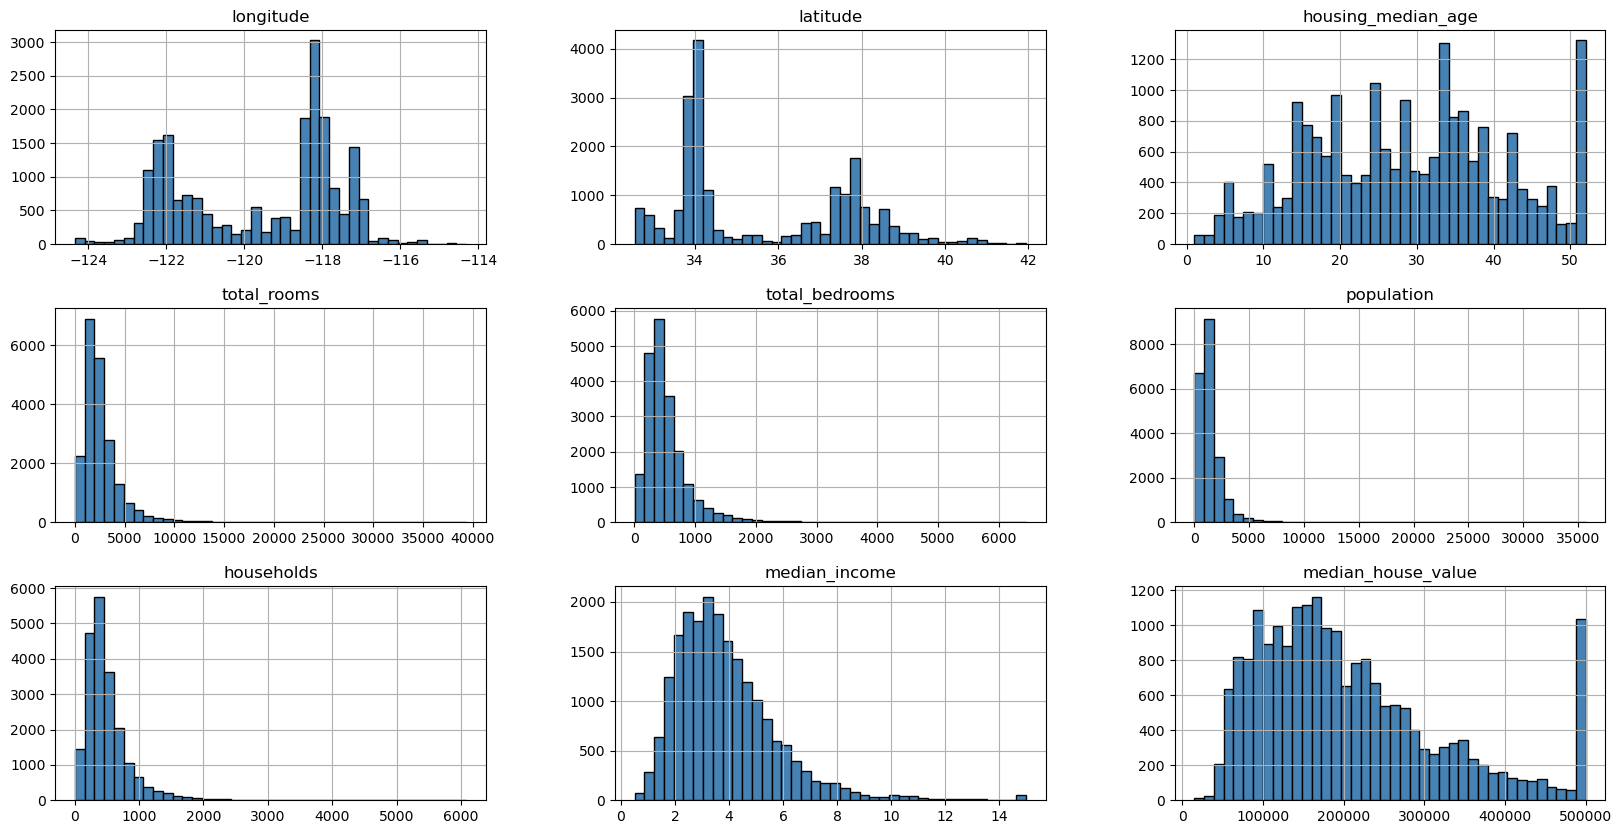

In [48]:
df_filled.hist(bins=40,color='steelblue',figsize=(20,10), edgecolor='black')
plt.show()

### Geographic Data Visualization
We can plot the latitude and longitude and use the house value as a color map to see where the most expensive houses are located.

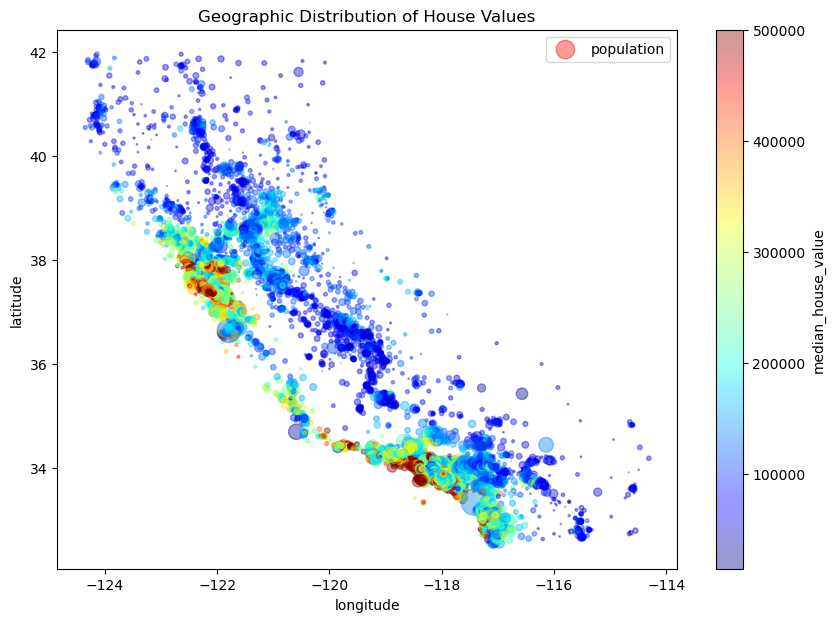

In [49]:
df_filled.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4,
             s=df_filled['population']/100, label='population', figsize=(10,7),
             c='median_house_value', cmap=plt.get_cmap('jet'), colorbar=True,
             sharex=False)
plt.title('Geographic Distribution of House Values')
plt.legend()
plt.show()

# Identifying skewed feature

In [50]:
numeric_feature = df_filled.select_dtypes(include=[np.number]).columns
print(numeric_feature)
skewness = df_filled[numeric_feature].skew()
print(skewness)


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')
longitude            -0.297801
latitude              0.465953
housing_median_age    0.060331
total_rooms           4.147343
total_bedrooms        3.481141
population            4.935858
households            3.410438
median_income         1.646657
median_house_value    0.977763
dtype: float64


In [51]:
skewed_features = skewness[skewness.abs() > 1].index.tolist()
print(skewed_features)

['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']


If skew>1 then feature are highly skewed.

The highly skew features are [total_rooms, total_bedrooms population, households, median_income]

**Key Observation**:

housing_median_age: It has roughly uniform distrubtion with spiked at 52 due to data capped at 52.

median_income:It is right skewed.

total_rooms, total_bedrooms,population,households:It is higly right skewed.

# Transforming skewed features

In [52]:
df_log = np.log1p(df_filled[skewed_features])

### Visualizing Skewed Features Before and After Log Transformation

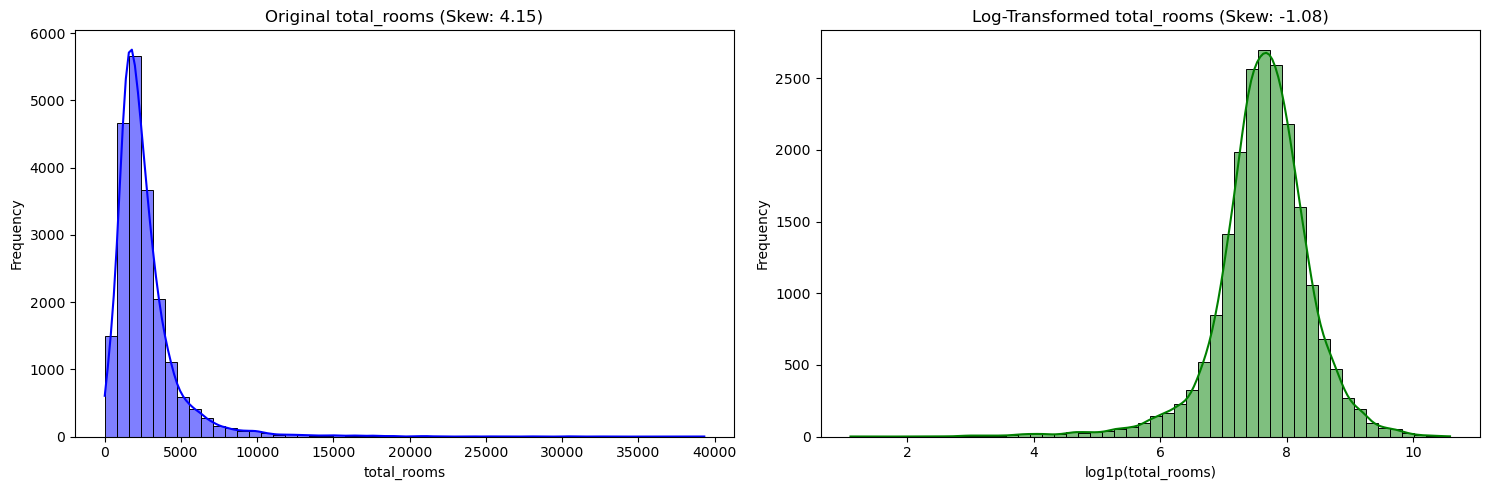

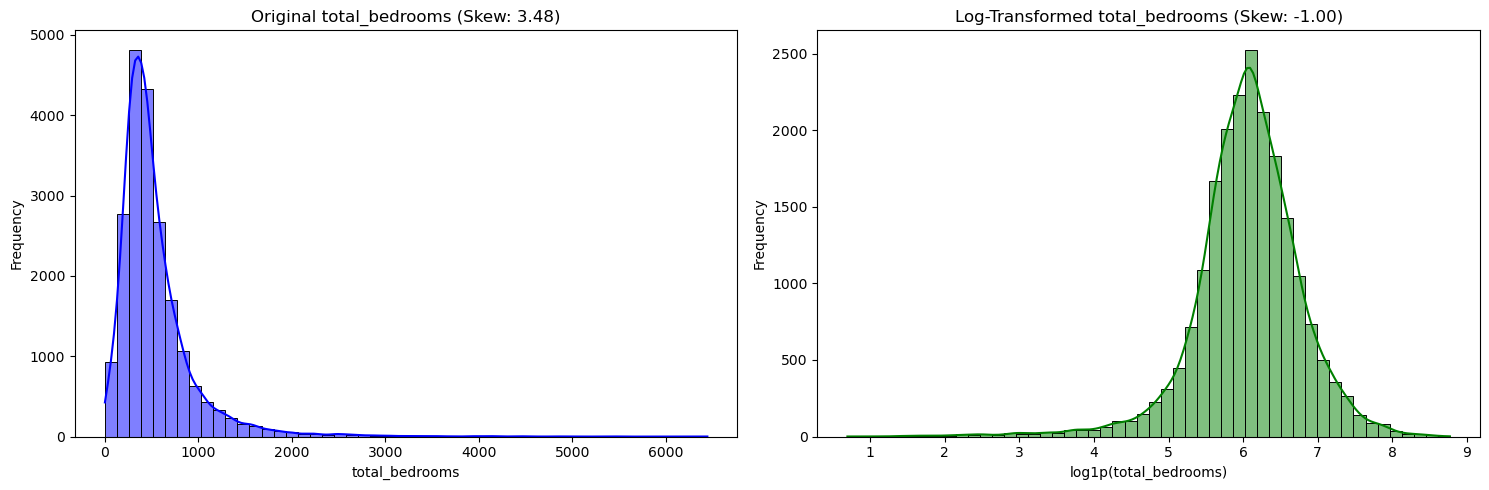

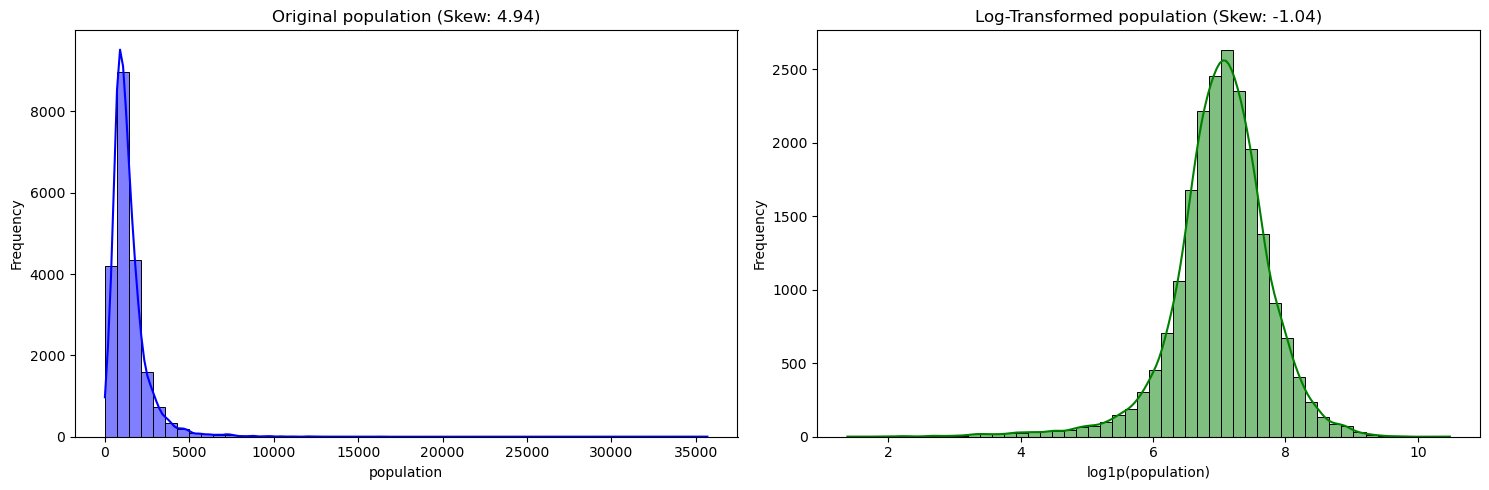

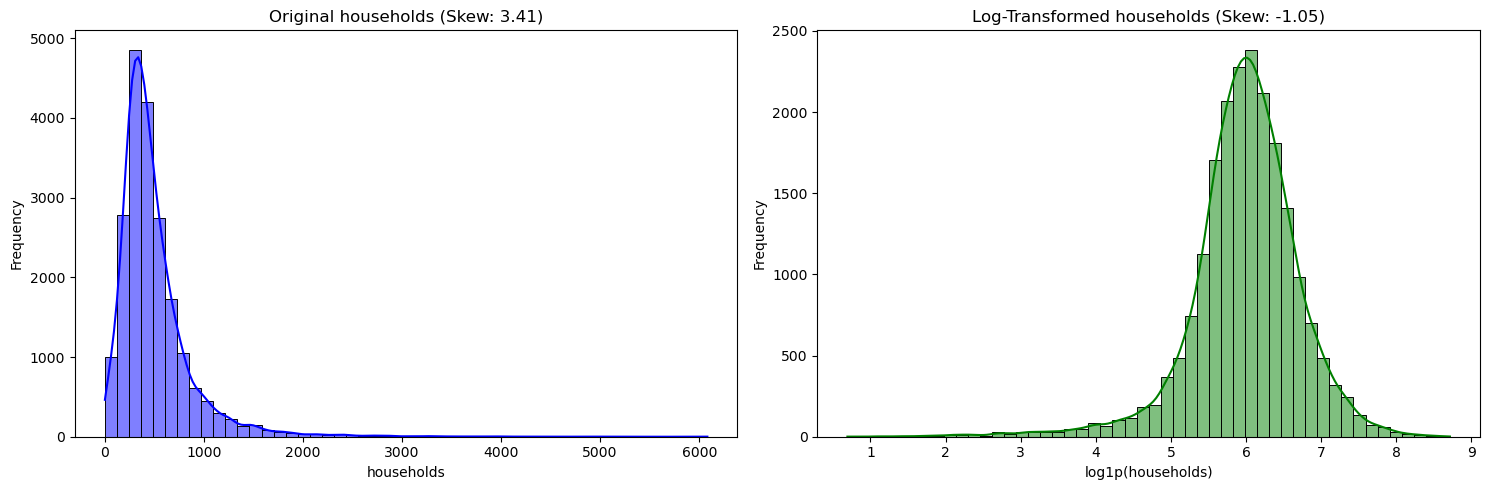

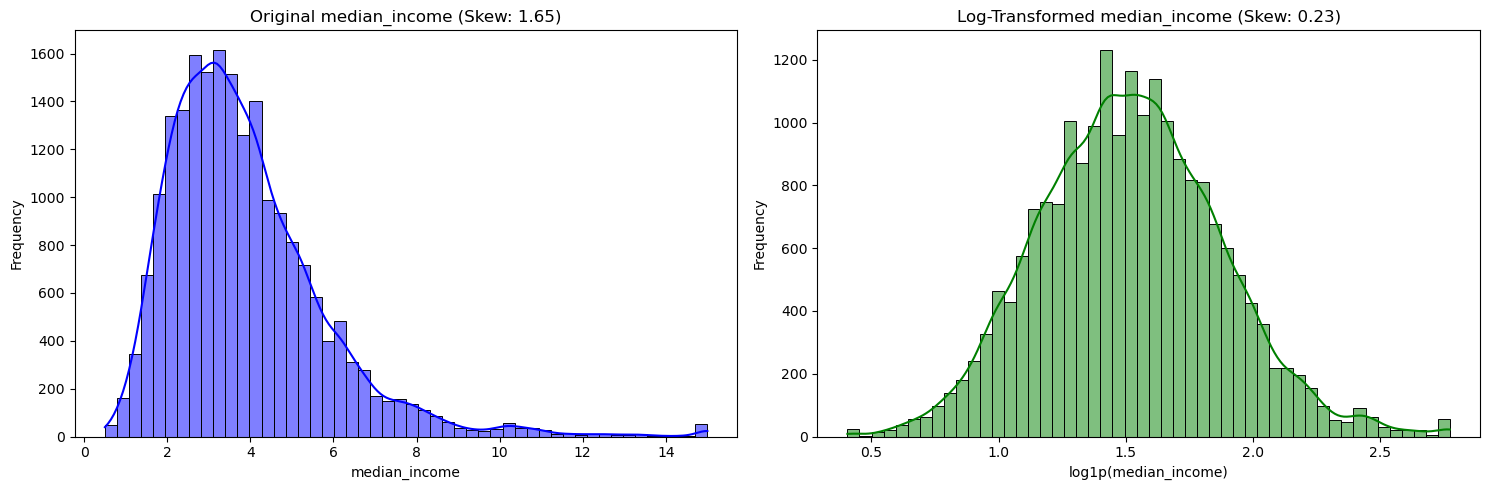

In [53]:
for feature in skewed_features:
    plt.figure(figsize=(15, 5))

    # Original skewed feature histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_filled[feature], bins=50, kde=True, color='blue')
    plt.title(f'Original {feature} (Skew: {df_filled[feature].skew():.2f})')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Log-transformed feature histogram
    plt.subplot(1, 2, 2)
    sns.histplot(df_log[feature], bins=50, kde=True, color='green')
    plt.title(f'Log-Transformed {feature} (Skew: {df_log[feature].skew():.2f})')
    plt.xlabel(f'log1p({feature})')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [54]:
non_skewed_numerical_features = [feature for feature in numeric_feature if feature not in skewed_features]
df_log_temp = df_filled[non_skewed_numerical_features].copy()


for feature in skewed_features:
    df_log_temp[feature] = df_log[feature]


df_log_temp['ocean_proximity'] = df_filled['ocean_proximity']


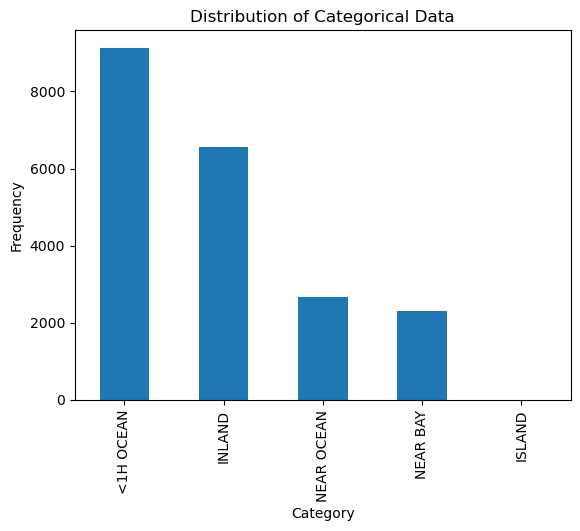

In [55]:
category_counts = df_log_temp['ocean_proximity'].value_counts()
category_counts.plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.title('Distribution of Categorical Data')
plt.show()

# One hot encoding

In [56]:
df_encoded = pd.get_dummies(df_log_temp, columns=['ocean_proximity'], drop_first=True)
print(df_encoded.head())

   longitude  latitude  housing_median_age  median_house_value  total_rooms  \
0    -122.23     37.88                41.0            452600.0     6.781058   
1    -122.22     37.86                21.0            358500.0     8.867850   
2    -122.24     37.85                52.0            352100.0     7.291656   
3    -122.25     37.85                52.0            341300.0     7.150701   
4    -122.25     37.85                52.0            342200.0     7.395108   

   total_bedrooms  population  households  median_income  \
0        4.867534    5.777652    4.844187       2.232720   
1        7.009409    7.784057    7.037906       2.230165   
2        5.252273    6.208590    5.181784       2.111110   
3        5.463832    6.326149    5.393628       1.893579   
4        5.638355    6.338594    5.560682       1.578195   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                   False                   False                      True   
1     

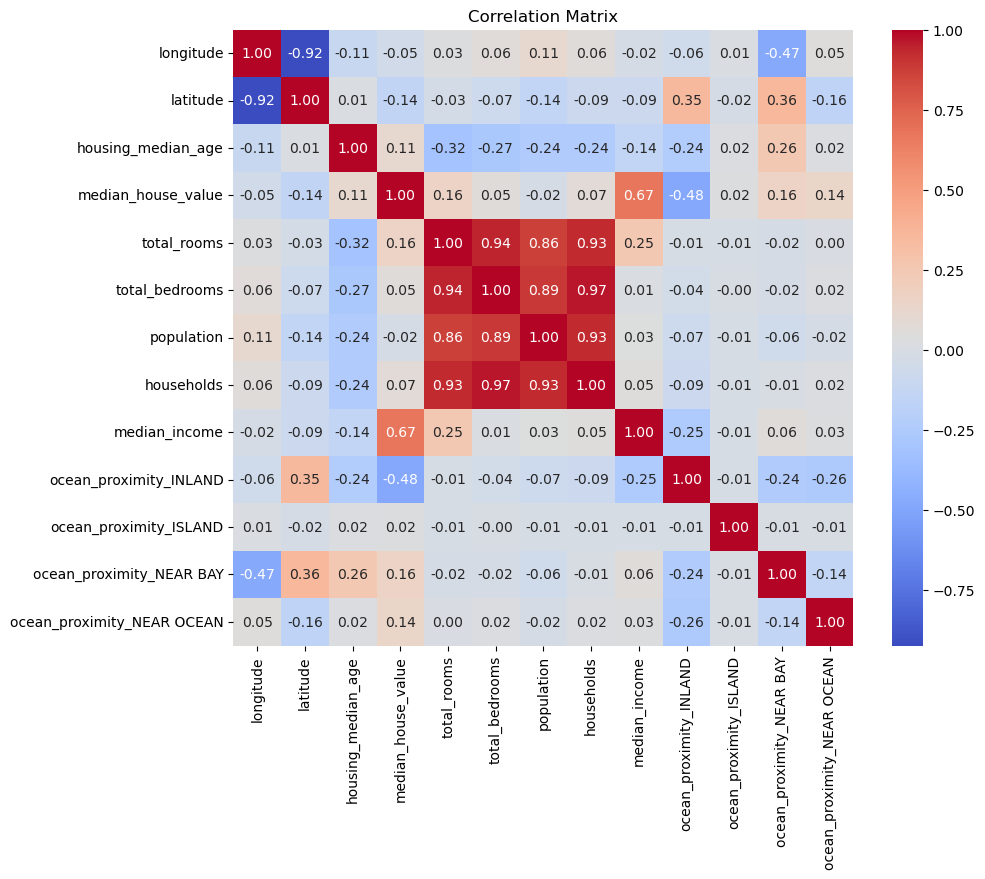

In [57]:
corr_matrix = df_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()